In [38]:
import numpy as np
import pandas as pd
from utils.utils import load_excelfile, generar_estadistica_por_departamento, generarMapaEstadisticaDepartamentos
from matplotlib import pyplot as plt

In [39]:
archivo2='/home/carbajal/Documents/SaludMental/2da entrega 20260210/Planilla completa.xlsx'

dfs = load_excelfile(archivo2)
segunda_entrega = 'EH' in dfs.keys()

## Ejemplo: acceder a una hoja
df_IAE = dfs["IAE"]
df_IAE_CDE = dfs["IAE_CDE"] if 'IAE_CDE' in dfs.keys() else dfs["CDE"]
df_IAE_CNV = dfs["IAE_CNV"] if 'IAE_CNV' in dfs.keys() else dfs["CNV"]
df_IAE_RUCAF = dfs["IAE_RUCAF"] 
df_IAE_SHARPS = dfs["IAE_SHARPS"] if 'IAE_SHARPS' in dfs.keys() else dfs["SHARPS"]
df_IAE_SIV = dfs["IAE_SIV"] if 'IAE_SIV' in dfs.keys() else dfs["SIV"]
df_IAE_EH = dfs["EH"] if 'EH' in dfs.keys() else None

['IAE', 'CDE', 'CNV', 'EH', 'SIV', 'SHARPS', 'IAE_RUCAF', 'Sheet1']


In [40]:
archivo1 = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"
dfs_pra_entrega = load_excelfile(archivo1)
df_IAE_primera_entrega = dfs_pra_entrega["IAE"]

['IAE', 'IAE_CDE', 'IAE_CNV', 'IAE_RUCAF', 'IAE_SHARPS', 'IAE_SIV', 'Hoja1']


In [41]:
df_IAE.shape

(19884, 29)

In [42]:
df_IAE_primera_entrega.keys(), df_IAE.keys()

(Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
        'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
        'FECHA IAE', 'EDAD', 'DECISIÓN'],
       dtype='object'),
 Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
        'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
        'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
        'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
        'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
        'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
        'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
        'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO'],
       dtype='object'))

In [43]:
df_IAE['MOTIVO'].value_counts()

MOTIVO
1.0        7
7.0        3
4.0        2
45100.0    1
45121.0    1
3.0        1
Name: count, dtype: int64

In [44]:
coincidentes = df_IAE_primera_entrega.merge(df_IAE, on='CEDULA', suffixes=('_df1','_df2'))

In [45]:
coincidentes.index

RangeIndex(start=0, stop=16071, step=1)

In [46]:
df_IAE[df_IAE['ID']==10720][['REGISTRO','FECHA IAE']]

,REGISTRO,FECHA IAE
7146,2025-03-18,2025-03-15
7349,2025-03-28,2025-03-27
7635,2025-04-14,2025-04-12
7731,2025-04-21,2025-04-17
7732,2025-04-21,2025-04-18
7793,2025-04-22,2025-04-20
7999,2025-05-05,2025-05-02
9394,2025-08-04,2025-08-04
10652,2025-10-11,2025-10-11


In [47]:
df_IAE.groupby("ID")["CEDULA"].nunique()

ID
8.0        1
21.0       1
30.0       1
32.0       1
38.0       1
          ..
13811.0    1
13838.0    1
13839.0    1
13853.0    1
13854.0    1
Name: CEDULA, Length: 12192, dtype: int64

In [48]:
ids_problematicos = (
    df_IAE.groupby("ID")["CEDULA"]
    .nunique()
    .loc[lambda x: x > 1]
)

In [49]:
ids_problematicos

ID
721.0      2
725.0      2
753.0      2
755.0      2
757.0      2
          ..
4549.0     2
4551.0     2
4553.0     2
4555.0     2
10815.0    2
Name: CEDULA, Length: 391, dtype: int64

In [13]:
len(coincidentes)

16071

In [14]:
len(coincidentes[(coincidentes['REGISTRO_df1']==coincidentes['REGISTRO_df2']) & (coincidentes['FECHA IAE_df1']!=coincidentes['FECHA IAE_df2'])])

17

In [15]:
len(coincidentes[(coincidentes['PRESTADOR']==coincidentes['PRESTADOR RECODIFICADO']) & (coincidentes['FECHA IAE_df1']!=coincidentes['FECHA IAE_df2'])])

5160

In [16]:
sum(coincidentes['PRESTADOR RECODIFICADO'].isnull())

5

In [17]:
coincidentes[coincidentes['IAE PREVIO_df1']==coincidentes['IAE PREVIO_df2']]

,CEDULA,PERSONA_df1,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO_df1,REGISTRO_df1,METODO_df1,IAE PREVIO_df1,FECHA IAE_df1,EDAD,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,NaN,NaN,SI,45069,NaN,Valentina Acosta,NaN,NaN,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,NaN,NaN,NaN,NaN,SI,45528,Valentina Acosta- LIC ROMANO,NaN,NaN,NaN
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Valentina Acosta - LIC ROMANO,N,NaN,NaN
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,NaN,NaN,NaN,NaN,NaN,Valentina Acosta,NaN,NaN,NaN,NaN
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,NaN,NaN,45160,NaN,NaN,LIC ROMANO,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16064,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,COMERO,COMERO - ROCHA,2024-08-31,Lesiones autoinfligidas,SI,2024-08-31,15.0,...,SI,NaN,NaN,45567,SI,45540,LIC ROMANO,NaN,NaN,NaN
16066,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,NaN,2023-01-14,Ingesta de Medicamentos,NO,2023-01-13,57.0,...,NO,NaN,SI,44941,NaN,Valentina Acosta,NaN,NaN,NaN,NaN
16067,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,CASMU-SANATORIO 2 Urgencia,2024-06-19,Ingesta de Medicamentos,SI,2024-06-17,58.0,...,SI,NaN,NaN,45564,SI,45526,Valentina Acosta-LIC ROMANO,N,NaN,NaN
16069,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,ASSE - SD,ASOCIACIÓN ESPAÑOLA,2023-09-12,Ingesta de Medicamentos,NO,2023-09-12,28.0,...,NaN,NaN,NaN,NaN,NaN,Valentina Acosta,Adjunto establecimiento de registro. ASESP ref...,NaN,NaN,NaN


In [18]:
coincidentes['IAE PREVIO_df1'].value_counts(),coincidentes['IAE PREVIO_df2'].value_counts()

(IAE PREVIO_df1
 SI              9919
 NO              4122
 NO SE INDICA    2030
 Name: count, dtype: int64,
 IAE PREVIO_df2
 SI                                      9924
 NO                                      3834
 NO SE INDICA                            1911
 Tratamiento en el prestador habitual      51
 Sin dato                                  23
 SI                                        19
 NO                                        12
 Tratamiento en clínica privada             3
 Name: count, dtype: int64)

In [19]:
coincidentes[coincidentes['IAE PREVIO_df1']=='NO SE INDICA'][]

SyntaxError: invalid syntax (1850576378.py, line 1)

In [20]:
len(coincidentes['CEDULA'].unique())

8326

In [21]:
len(df_IAE['CEDULA'].unique())

16666

In [22]:
coincidentes.keys()

Index(['CEDULA', 'PERSONA_df1', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO_df1', 'REGISTRO_df1', 'METODO_df1',
       'IAE PREVIO_df1', 'FECHA IAE_df1', 'EDAD', 'DECISIÓN', 'ID', 'NOMBRE',
       'APELLIDO', 'PERSONA_df2', 'FECHA NACIMIENTO', 'DECISION', 'PRESTADOR',
       'ESTABLECIMIENTO REGISTRO_df2', 'REGISTRO_df2', 'METODO_df2',
       'IAE PREVIO_df2', 'FECHA IAE_df2', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO'],
      dtype='object')

In [23]:
df_IAE['IAE PREVIO'].unique()

array(['NO SE INDICA', 'SI', 'NO', nan, 'Sin dato',
       'Tratamiento en el prestador habitual', 'NO ', 'SI ',
       'Tratamiento en clínica privada',
       '                                                                                           '],
      dtype=object)

In [24]:
no_comunes = df_IAE[~df_IAE['CEDULA'].isin(df_IAE_primera_entrega['CEDULA'])]

In [25]:
no_comunes.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO'],
      dtype='object')

In [26]:
no_comunes.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO'],
      dtype='object')

In [27]:
no_comunes['ID'].value_counts()

ID
11151.0    10
10720.0     9
10513.0     8
12009.0     7
11198.0     6
           ..
1302.0      1
6189.0      1
1616.0      1
929.0       1
2195.0      1
Name: count, Length: 4136, dtype: int64

In [28]:
no_comunes[no_comunes['ID']==11151]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
7800,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-04-22,...,SI,NaN,NaN,45790,SD,NaN,LIC ROMANO,NaN,NaN,NaN
7971,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-05-03,...,SI,NaN,NaN,45825,SD,NaN,Valentina Acosta,NaN,NaN,NaN
8021,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-05-06,...,NaN,NaN,NaN,45825,SI,45783,Valentina Acosta,N,NaN,NaN
8194,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - HOSPITAL PASTEUR,HOSPITAL PASTEUR,2025-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,Valentina Acosta-LIC ROMANO,N,NaN,NaN
9161,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-07-24,...,NaN,NaN,NaN,NaN,SI,45862,Valentina Acosta,N,NaN,NaN
9382,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - HOSPITAL PASTEUR,HOSPITAL PASTEUR,2025-08-04,...,NaN,NaN,NaN,NaN,NO,NaN,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN
9864,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-08-30,...,NaN,NaN,NaN,NaN,NO,NaN,LIC ROMANO,N,NaN,NaN
9881,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-08-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9884,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-08-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9885,11151.0,6a5490fc10bb634e0198d6471288fbcbdbc747f6ef499f...,NaN,NaN,Femenino,2007-01-01 00:00:00,NaN,ASSE - CENTRO DE SALUD JARDINES DEL HIPODROMO,CENTRO DE SALUD JARDINES DEL HIPODROMO,2025-08-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
no_comunes['ID'].value_counts()

ID
11151.0    10
10720.0     9
10513.0     8
12009.0     7
11198.0     6
           ..
1302.0      1
6189.0      1
1616.0      1
929.0       1
2195.0      1
Name: count, Length: 4136, dtype: int64

In [30]:
print(no_comunes.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9099 entries, 23 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         4806 non-null   float64       
 1   CEDULA                                     9088 non-null   object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    8693 non-null   object        
 5   FECHA NACIMIENTO                           4394 non-null   object        
 6   DECISION                                   110 non-null    object        
 7   PRESTADOR                                  4806 non-null   object        
 8   ESTABLECIMIENTO REGISTRO                   4773 non-null   object        
 9   REGISTRO              

In [31]:
df_julio = df_IAE[(df_IAE['REGISTRO'] >= '2023-07-01') & (df_IAE['REGISTRO'] < '2023-08-01')]
df_julio

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
31,2948.0,76e96691329d077b639f4cf81f9f1fc8b053ff0b432b64...,NaN,NaN,Femenino,1968-11-01 00:00:00,RESUELTO,CAAMEPA IAMPP,NaN,2023-07-06,...,NO,4.0,31/07/2023 COMITÉ,SI,45133,Valentina Acosta,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10129,NaN,7834576937f411029f97e22a9d01beaf1deeaed535d966...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12446,NaN,157070a400e8b90298340bf79ec515e88bd9dd51cd3cd9...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13180,NaN,1e939367f837a635b53b90c792936155446754bc746935...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19798,NaN,829f10b79b9295fb6ee6c4ec368046ebb570821374cdeb...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19829,NaN,a9b0bcabb1a8449e602a1f18d42686868074147f180a84...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19830,NaN,88602fbb9159e2afbb65e617fecc20ab79cb586c4452a0...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19861,NaN,efe30149fdbd423b75779dae5f73d368e0b528d7530de3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df_julio = df_IAE_primera_entrega[(df_IAE_primera_entrega['REGISTRO'] >= '2023-07-01') & (df_IAE_primera_entrega['REGISTRO'] < '2023-08-01')]
df_julio


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
7,003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f...,Masculino,1996-04-01,ASSE - BELLA UNION,HOSPITAL BELLA UNION,2023-07-11,Otros,SI,2023-06-30,27.0,NO CUMPLE PROTOCOLO
19,007a5dd46377a17f971e0f1f38a46489679b3346323413...,Masculino,1996-07-01,ASSE - ROCHA,HOSPITAL DE ROCHA,2023-07-20,Lesiones autoinfligidas,NO,2023-07-19,26.0,NO CUMPLE PROTOCOLO
53,0124230c21624a07c5f200529a47df92671c7bff4443f2...,Masculino,2005-12-01,CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORI...,NaN,2023-07-07,Otros,NO,2023-07-07,17.0,RESUELTO
56,0131dfab7958fc381e6c1ccdc524c6b48f444436baefbb...,Femenino,1992-04-01,CRAME,NaN,2023-07-24,Ingesta de Medicamentos,NO,2023-07-24,31.0,RESUELTO
72,019d3bd85bb57a17a8ba5d38c13f2b208b9f54fe643aef...,Masculino,2007-12-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,NaN,2023-07-24,Ahorcamiento o asfixia,NO,2023-07-24,15.0,RESUELTO
...,...,...,...,...,...,...,...,...,...,...,...
10279,fc81373b3840abac1e888eec2541780af6cde05655f25e...,Femenino,1984-05-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,NaN,2023-07-14,Ingesta de Medicamentos,SI,2023-07-14,39.0,RESUELTO
10321,fd64b4637915827551985995fed78a69a7863fb0a93177...,Femenino,2012-10-01,MEDICA URUGUAYA MUCAM,NaN,2023-07-26,Lesiones autoinfligidas,NO,2023-07-22,10.0,RESUELTO
10400,ff5a3a7e073e649548692f3b675d0853ba4c759e9ad9e8...,Femenino,1992-01-01,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2023-07-03,Otros,SI,2023-06-30,31.0,NO CUMPLE PROTOCOLO
10416,ffbacea7e7a83c5202df1c51e4a650869e3194d4ad423e...,Masculino,1997-03-01,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2023-07-31,Ingesta de Medicamentos,SI,2023-07-28,26.0,NO CUMPLE PROTOCOLO


In [33]:
df_IAE['REGISTRO'].value_counts()

REGISTRO
2025-10-24    74
2025-01-29    66
2025-01-20    64
2025-04-21    55
2025-02-11    54
              ..
2023-01-31     1
2023-05-17     1
2023-09-05     1
2023-08-13     1
2023-10-22     1
Name: count, Length: 1087, dtype: int64

In [37]:
df_IAE['FECHA IAE'].isnull().sum(), df_IAE['REGISTRO'].isnull().sum()

(np.int64(4298), np.int64(4033))

/tmp/ipykernel_41731/2124686189.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  conteo_mensual = df_IAE.resample('M', on='FECHA IAE').size()


<Axes: xlabel='FECHA IAE'>

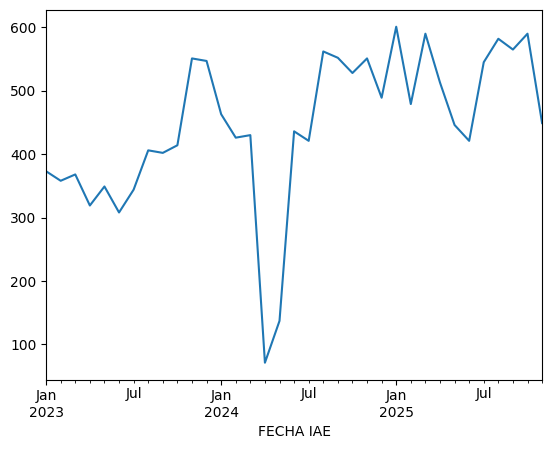

In [35]:
#df_IAE['REGISTRO'].hist(xrot=90, bins=36)
conteo_mensual = df_IAE.resample('M', on='FECHA IAE').size()
conteo_mensual.plot()

/tmp/ipykernel_19778/1325929730.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  conteo_mensual = df_IAE_primera_entrega.resample('M', on='FECHA IAE').size()


<Axes: xlabel='FECHA IAE'>

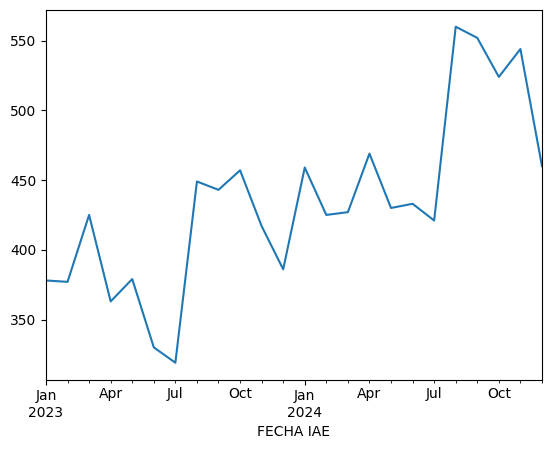

In [115]:
conteo_mensual = df_IAE_primera_entrega.resample('M', on='FECHA IAE').size()
conteo_mensual.plot()

In [116]:
conteo_mensual

FECHA IAE
2023-01-31    378
2023-02-28    377
2023-03-31    425
2023-04-30    363
2023-05-31    379
2023-06-30    330
2023-07-31    319
2023-08-31    449
2023-09-30    443
2023-10-31    457
2023-11-30    417
2023-12-31    386
2024-01-31    459
2024-02-29    425
2024-03-31    427
2024-04-30    469
2024-05-31    430
2024-06-30    433
2024-07-31    421
2024-08-31    560
2024-09-30    552
2024-10-31    524
2024-11-30    544
2024-12-31    460
dtype: int64

In [118]:
df_IAE_primera_entrega['IAE PREVIO'].value_counts()

IAE PREVIO
SI              5327
NO              3498
NO SE INDICA    1602
Name: count, dtype: int64

In [117]:
df_IAE['IAE PREVIO'].value_counts()

IAE PREVIO
SI                                                                                             7802
NO                                                                                             4824
NO SE INDICA                                                                                   2170
Tratamiento en el prestador habitual                                                            121
Sin dato                                                                                         33
NO                                                                                               10
SI                                                                                                8
Tratamiento en clínica privada                                                                    4
                                                                                                  1
Name: count, dtype: int64